In [13]:
import itertools
import mujoco
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.spatial.transform import Rotation as R

In [14]:
class JumpSimulator:
    def __init__(self, horizontal_velocity, vertical_velocity, incident_angle, angular_velocity):
        self.hv = horizontal_velocity
        self.vv = vertical_velocity
        self.ia = incident_angle
        self.av = angular_velocity

        self.num_steps = 600
        self.positions = []
        self.num_contacts = []
        self.saved_qpos = []
        self.max_height_after = 0
        self.max_height_after_idx = None
        self.first_contact = None
        self.first_contact_end = None

        self._setup_sim()

        def _setup_sim(self):
            half_rod_length = 0.9144
            xml = f"""
            <mujoco>
                <option gravity="0 0 -9.81"/>
                <worldbody>
                    <camera name="sideview" pos="2 0 0.5" euler="0 90 90"/>
                    <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" rgba="0 0.6 0 1" friction="1 0 0"/>
                    <body name="rodd" pos="0 -0.5 1">
                        <freejoint/>
                        <geom name="rod" type="cylinder" pos="0 0 0" size="0.001 {half_rod_length}" rgba="1 1 1 1" solref="0.001 0" solimp="1 1 1 1 1" friction="1 0 0" density="1000"/>
                    </body>
                </worldbody>
            </mujoco>
            """
            self.model = mujoco.MjModel.from_xml_string(xml)
            self.data = mujoco.MjData(self.model)

            self.data.qpos[0:3] = [0, -0.5, 0.01 + np.cos(self.ia)*half_rod_length]
            self.data.qpos[3:7] = [np.cos(self.ia / 2), np.sin(self.ia / 2), 0, 0]
            self.data.qvel[0:6] = [0, self.hv, self.vv, self.av, 0, 0]

            self.rod_geom_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_GEOM, "rod")

    def run(self):
        for _ in range(self.num_steps):
            mujoco.mj_step(self.model, self.data)
            self.positions.append(self.data.xipos[1].copy())
            self.num_contacts.append(self.data.ncon)
            self.saved_qpos.append(self.data.qpos.copy())

        self.positions = np.array(self.positions)
        self.saved_qpos = np.array(self.saved_qpos)
        self._detect_contacts()
        self._compute_max_height()

    def _detect_contacts(self):
        for i, n in enumerate(self.num_contacts):
            if n > 0 and self.first_contact is None:
                self.first_contact = i
            if self.first_contact is not None and n == 0:
                self.first_contact_end = i
                break

    def _compute_max_height(self):
        if self.first_contact_end is not None:
            z_after = self.positions[self.first_contact_end:, 2]
            if len(z_after) > 0:
                self.max_height_after = np.max(z_after)
                self.max_height_after_idx = np.argmax(z_after) + self.first_contact_end

    def get_max_height(self):
        return self.max_height_after

    def print_summary(self):
        if self.first_contact is not None and self.first_contact_end is not None:
            duration = self.first_contact_end - self.first_contact
            print(f"First collision lasts {duration} steps")
        elif self.first_contact is not None:
            print(f"First collision starts at step {self.first_contact} and lasts until the end of the simulation")
        else:
            print("No collision detected in the simulation")

        if self.max_height_after_idx is not None:
            print(f"Max height after collision: {self.max_height_after:.4f} m at step {self.max_height_after_idx}")
        else:
            print("No valid height found after collision.")

    def analyze_orientation_at_events(self):
        if self.first_contact is None or self.max_height_after_idx is None:
            return

        for step, label in [(self.first_contact, "contact"), (self.max_height_after_idx, "peak")]:
            quat = self.saved_qpos[step, 3:7]
            quat_xyzw = [quat[1], quat[2], quat[3], quat[0]]
            rot_matrix = R.from_quat(quat_xyzw).as_matrix()
            axis_yz = rot_matrix[1:, 2]
            angle_rad = np.arctan2(axis_yz[1], axis_yz[0])
            angle_deg = np.degrees(angle_rad)
            print(f"Angle at {label} (step {step}): {angle_deg:.2f} degrees")

    def summarize_parameters(self):
        print("Simulation Parameters:")
        print(f"  Horizontal Velocity: {self.hv:.2f} m/s")
        print(f"  Vertical Velocity: {self.vv:.2f} m/s")
        print(f"  Incident Angle: {np.degrees(self.ia):.2f} degrees")
        print(f"  Angular Velocity: {self.av:.2f} rad/s")

    def animate_jump(self):
        frames = []
        num_frames = min(200, len(self.saved_qpos))
    
        renderer = mujoco.Renderer(self.model)
        data_render = mujoco.MjData(self.model)
        for i in range(num_frames):
            data_render.qpos[:] = self.saved_qpos[i]
            # If you also saved velocities:
            # data_render.qvel[:] = self.saved_qvel[i]
            mujoco.mj_forward(self.model, data_render)
            renderer.update_scene(data_render, camera="sideview")
            frame = renderer.render()
            frames.append(frame)
    
        fig, ax = plt.subplots()
        im = ax.imshow(frames[0])
        ax.axis('off')
    
        def update(i):
            im.set_data(frames[i])
            return [im]
    
        ani = FuncAnimation(fig, update, frames=num_frames, interval=20, blit=True)
        plt.close(fig)
        display(HTML(ani.to_jshtml()))



In [15]:
def run_heatmap(hv, vv, ia_deg_range, av_range):

    ia_rad_range = np.radians(ia_deg_range)
    heights = np.zeros((len(av_range), len(ia_rad_range)))

    for i, av in enumerate(av_range):
        for j, ia in enumerate(ia_rad_range):
            sim = JumpSimulator(horizontal_velocity=hv,
                            vertical_velocity=vv,
                            incident_angle=ia,
                            angular_velocity=av)
            sim.run()
            heights[i, j] = sim.get_max_height()

    plt.figure(figsize=(10, 6))
    extent = [ia_deg_range[0], ia_deg_range[-1], av_range[0], av_range[-1]]

    cmap = plt.get_cmap('Reds').copy()
    cmap.set_bad(color='gray')  # NaN will be gray

    masked_heights = np.ma.masked_invalid(heights)  # Mask NaNs

    #plt.imshow(heights, extent=extent, origin='lower', aspect='auto', cmap='Reds')
    plt.imshow(masked_heights, extent=extent, origin='lower', aspect='auto', cmap=cmap)
    plt.colorbar(label='Max Jump Height (m)')
    plt.xlabel('Incident Angle (degrees)')
    plt.ylabel('Angular Velocity (rad/s)')
    plt.title('Heatmap of Max Jump Height vs. Incident Angle and Angular Velocity')
    plt.grid(False)
    plt.show()

In [16]:
def improved_sensitivity_heatmaps(sim_class, base_hv, base_vv, ia_deg_range, av_range, delta=0.3):
    """Improved heatmap function for jump sensitivity analysis with better color scaling and error handling."""
    ia_rad_range = np.radians(ia_deg_range)
    hv_vals = [base_hv - delta, base_hv, base_hv + delta]
    vv_vals = [base_vv - delta, base_vv, base_vv + delta]

    all_heights = []

    for hv in hv_vals:
        for vv in vv_vals:
            heights = np.zeros((len(av_range), len(ia_rad_range)))
            for m, av in enumerate(av_range):
                for n, ia in enumerate(ia_rad_range):
                    try:
                        sim = sim_class(horizontal_velocity=hv,
                                        vertical_velocity=vv,
                                        incident_angle=ia,
                                        angular_velocity=av)
                        sim.run()
                        heights[m, n] = sim.get_max_height()
                    except Exception:
                        heights[m, n] = np.nan
            all_heights.append(heights)

    all_data = np.array(all_heights)
    vmin = np.nanmin(all_data)
    vmax = np.nanmax(all_data)

    fig, axes = plt.subplots(len(hv_vals), len(vv_vals), figsize=(18, 12), sharex=True, sharey=True)
    fig.suptitle("Sensitivity of Max Jump Height to Small Changes in Horizontal and Vertical Velocity", fontsize=16)

    idx = 0
    for i, hv in enumerate(hv_vals):
        for j, vv in enumerate(vv_vals):
            heights = all_heights[idx]
            idx += 1

            ax = axes[i, j]
            extent = [ia_deg_range[0], ia_deg_range[-1], av_range[0], av_range[-1]]
            im = ax.imshow(heights, extent=extent, origin='lower', aspect='auto', cmap='Reds', vmin=vmin, vmax=vmax)
            ax.set_title(f"hv={hv:.2f}, vv={vv:.2f}")
            if i == len(hv_vals) - 1:
                ax.set_xlabel("Incident Angle (deg)")
            if j == 0:
                ax.set_ylabel("Angular Velocity (rad/s)")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.95, label='Max Jump Height (m)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

C:\Users\eligi\AppData\Local\Temp\ipykernel_11184\1452116665.py:26: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(all_data)
C:\Users\eligi\AppData\Local\Temp\ipykernel_11184\1452116665.py:27: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(all_data)
C:\Users\eligi\AppData\Local\Temp\ipykernel_11184\1452116665.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


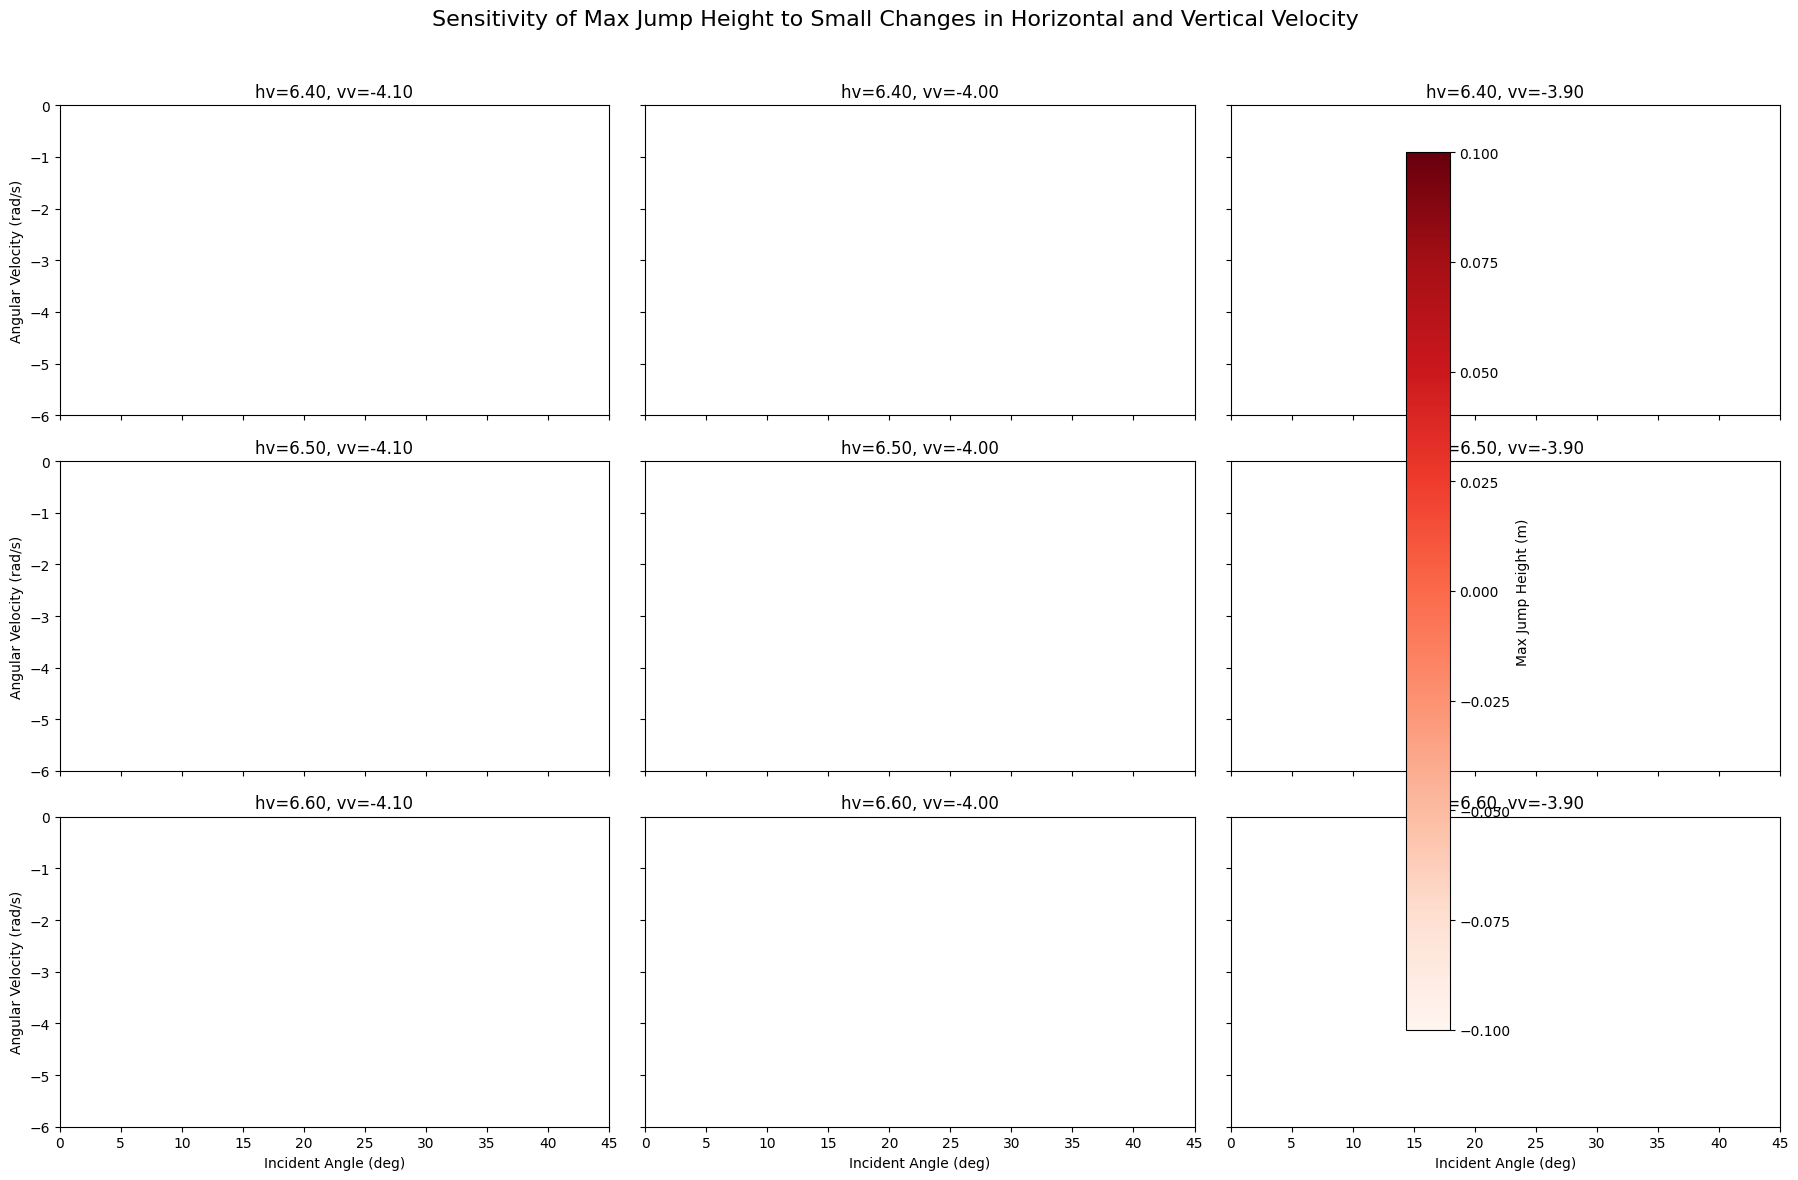

In [17]:
improved_sensitivity_heatmaps(
    JumpSimulator,
    base_hv=6.5,
    base_vv=-4.0,
    ia_deg_range=np.linspace(0, 45, 20),
    av_range=np.linspace(-6, 0, 20),
    delta=0.1
)

In [18]:
run_heatmap(
    JumpSimulator,
    hv=6.5,
    vv=4.0,
    ia_deg_range=np.linspace(0, 45, 200),  # smaller steps between incident angles
    av_range=np.linspace(-6, 0, 200)        # smaller steps between angular velocities
)

TypeError: run_heatmap() got multiple values for argument 'hv'